**Importando o arquivo com os retornos das ações que compõem o IBOVESPA**

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns

outlier_retorno=pd.read_csv('/content/drive/MyDrive/bootcamp FINOR/ibov_retornos.csv', parse_dates=['Date'])

Conforme documentado no *Guia de dados & EDA*, vamos verificar a existência de ativos que apresentem retornos **maiores do que 15%** a fim de entender quais ações apresentam um comportamento mais volátil.

In [35]:
limite_outlier = 0.15

ticker_columns = [col for col in outlier_retorno.columns if col != 'Date']
df_melted = outlier_retorno.melt(id_vars=['Date'], value_vars=ticker_columns, var_name='Ticker', value_name='Retorno')
df_melted['Date'] = pd.to_datetime(df_melted['Date'])

outlier_retornoibv = df_melted[df_melted['Retorno'].abs() > limite_outlier]['Ticker'].value_counts()
__builtins__.print('Ações com retornos diários > 15% (IBOVESPA):')
__builtins__.print(outlier_retornoibv[outlier_retornoibv > 0].sort_values(ascending=False).head(15))

Ações com retornos diários > 15% (IBOVESPA):
Ticker
BRKM5.SA     13
PRIO3.SA     13
MGLU3.SA     11
HAPV3.SA      9
PETR3.SA      9
BPAC11.SA     8
AXIA3.SA      8
COGN3.SA      8
AXIA6.SA      7
PETR4.SA      7
YDUQ3.SA      7
CSNA3.SA      6
USIM5.SA      6
MBRF3.SA      5
CYRE3.SA      5
Name: count, dtype: int64


Dentre as 62 ações analisadas dentro da nossa amostra, 15 delas apresentaram retornos diários extremos (>15%)

---

Dessa maneira, com o objetivo de obter informações mais precisas acerca de quais ativos possuem maior influência no comportamento do indíce IBOVESPA em períodos turbulentos, cabe analisar se esses retornos extremos coincidem com as datas dos eventos de crise enfrentrados pelo índice.

In [36]:
acoes_analise = [
    'BRKM5.SA', 'PRIO3.SA', 'MGLU3.SA', 'HAPV3.SA', 'PETR3.SA',
    'BPAC11.SA', 'AXIA3.SA', 'COGN3.SA', 'AXIA6.SA', 'PETR4.SA',
    'YDUQ3.SA', 'CSNA3.SA', 'USIM5.SA', 'MBRF3.SA', 'CYRE3.SA'
]

datas_analise = [
    '2018-06-18', '2020-03-18', '2020-03-19',
    '2020-03-20', '2020-03-23', '2020-03-24', '2020-04-03'
]

if 'Date' in outlier_retorno.columns:
    df_filtrado = outlier_retorno.set_index('Date')
else:
    df_filtrado = outlier_retorno.copy()

df_recorte = df_filtrado.loc[datas_analise, acoes_analise]

retornos_extremos = df_recorte[df_recorte.abs() > 0.15].stack().reset_index()
retornos_extremos.columns = ['Data', 'Ticker', 'Retorno']

retornos_extremos['Retorno'] = (retornos_extremos['Retorno'] * 100).round(2).astype(str) + '%'

print("Ocorrências de retornos extremos (> 15%):")
print(retornos_extremos.to_string(index=False))

Ocorrências de retornos extremos (> 15%):
      Data    Ticker Retorno
2020-03-18  BRKM5.SA -28.07%
2020-03-18  PRIO3.SA -35.02%
2020-03-18  MGLU3.SA -21.08%
2020-03-18  HAPV3.SA -16.95%
2020-03-18  PETR3.SA -16.87%
2020-03-18  AXIA3.SA  -21.7%
2020-03-18  COGN3.SA -21.85%
2020-03-18  AXIA6.SA -17.56%
2020-03-18  USIM5.SA -23.87%
2020-03-18  MBRF3.SA -20.43%
2020-03-18  CYRE3.SA -23.13%
2020-03-23  BRKM5.SA -15.85%
2020-03-24  MGLU3.SA  19.41%
2020-03-24 BPAC11.SA   22.2%
2020-03-24  CYRE3.SA   16.6%


Analisar quais foram as ações que mais se repetiram nesse período.

In [37]:
contagem_acoes = retornos_extremos['Ticker'].value_counts()

print("\nQuantidade de vezes que cada ação teve retorno extremo nestas datas:")
print(contagem_acoes)


Quantidade de vezes que cada ação teve retorno extremo nestas datas:
Ticker
BRKM5.SA     2
MGLU3.SA     2
CYRE3.SA     2
PRIO3.SA     1
HAPV3.SA     1
PETR3.SA     1
COGN3.SA     1
AXIA3.SA     1
AXIA6.SA     1
USIM5.SA     1
MBRF3.SA     1
BPAC11.SA    1
Name: count, dtype: int64


Fica evidente a necessidade de prestar atenção no comportamento desses ativos: **BRKM5.SA, MGLU3.SA, CYRE3.SA**

Além disso, cabe destacar que as três ações citadas anteriormente operam em setores distintos, o que contribui para a diversificação da carteira teórica.

**Braskem PNA (BRKM5.SA):** Setor petroquímico

---


**Magazine Luiza ON (MGLU3.SA)**: Setor de varejo

Fortemente afetada pelo fechamento de suas lojas físicas em virtude da pandemia de covid-19, mas voltou a crescer em razão do aumento de vendas online.

---


**Cyrela ON (CYRE3.SA):** Setor de construção civil


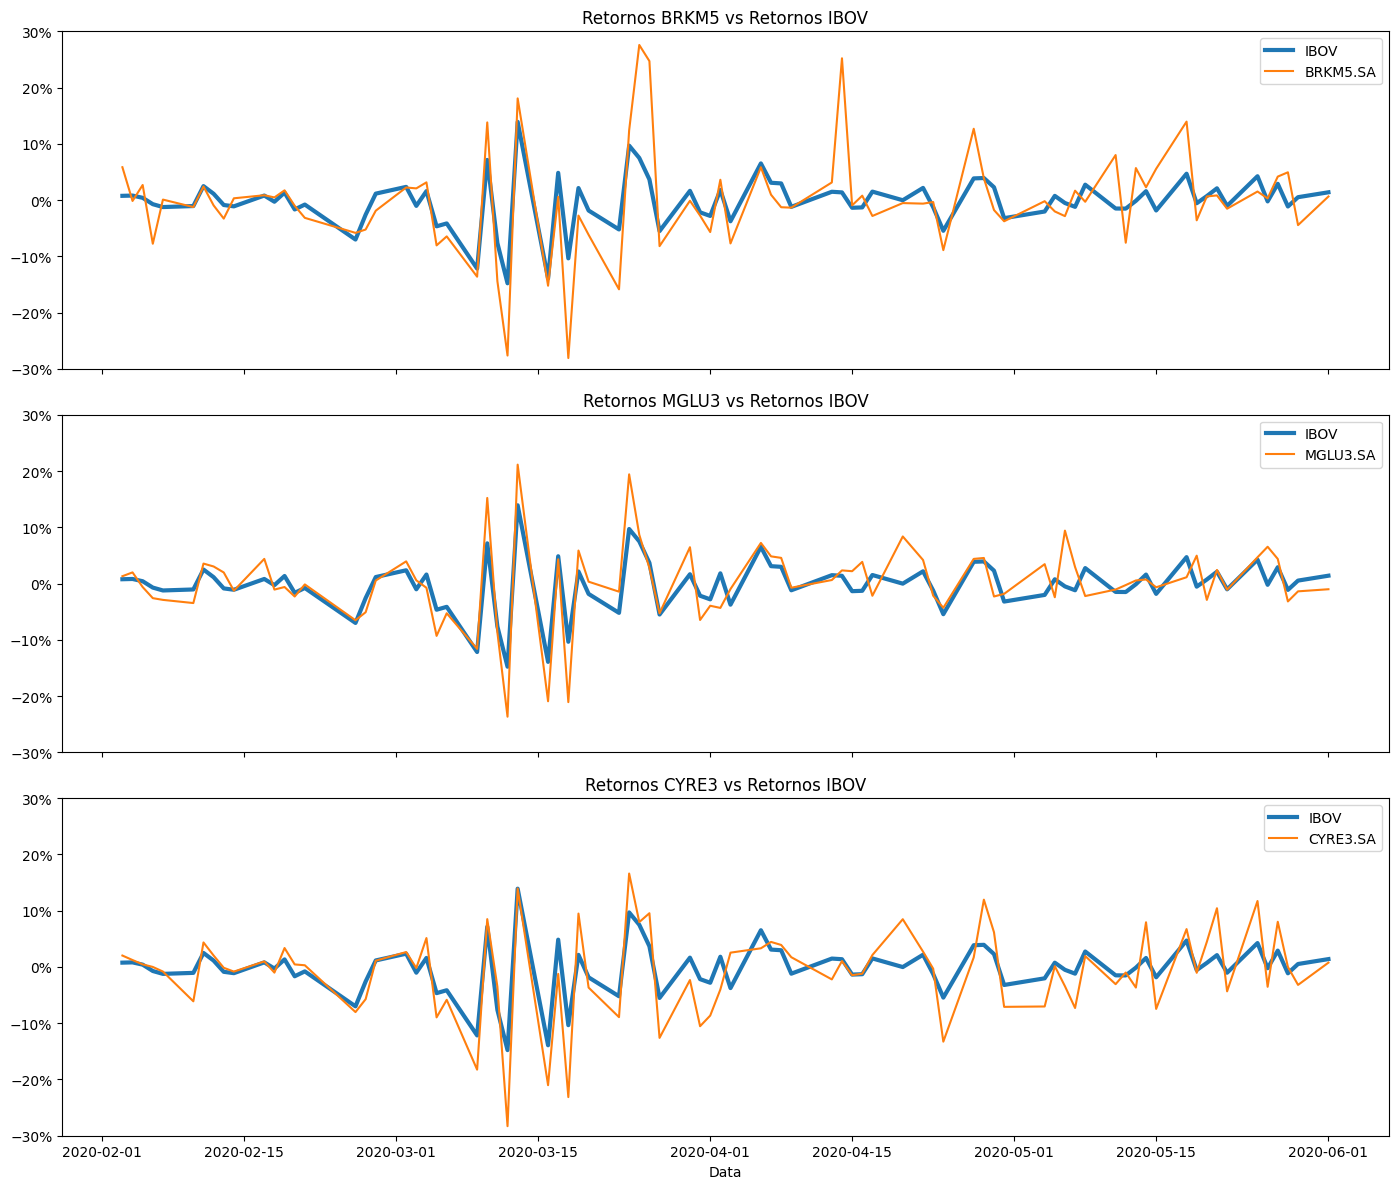

In [38]:
indice_ibov = pd.read_csv('/content/drive/MyDrive/bootcamp FINOR/ibov_indice.csv')

indice_ibov['Date'] = pd.to_datetime(indice_ibov['Date'])
indice_ibov['Retorno_IBOV'] = indice_ibov['^BVSP'].pct_change()

inicio = '2020-02-01'
fim = '2020-06-01'

ibov_2020 = indice_ibov[
    (indice_ibov['Date'] >= inicio) &
    (indice_ibov['Date'] <= fim)
]

fig, axs = plt.subplots(3, 1, figsize=(14,12), sharex=True)

# BRKM5
axs[0].plot(
    ibov_2020['Date'],
    ibov_2020['Retorno_IBOV'],
    label='IBOV',
    linewidth=3
)

axs[0].plot(
    acoes_2020['Date'],
    acoes_2020['BRKM5.SA'],
    label='BRKM5.SA'
)

axs[0].set_title('Retornos BRKM5 vs Retornos IBOV')
axs[0].legend()

# MGLU3
axs[1].plot(
    ibov_2020['Date'],
    ibov_2020['Retorno_IBOV'],
    label='IBOV',
    linewidth=3
)

axs[1].plot(
    acoes_2020['Date'],
    acoes_2020['MGLU3.SA'],
    label='MGLU3.SA'
)

axs[1].set_title('Retornos MGLU3 vs Retornos IBOV')
axs[1].legend()

# IBOV
axs[2].plot(
    ibov_2020['Date'],
    ibov_2020['Retorno_IBOV'],
    label='IBOV',
    linewidth=3
)

# CYRE3
axs[2].plot(
    acoes_2020['Date'],
    acoes_2020['CYRE3.SA'],
    label='CYRE3.SA'
)

axs[2].set_title('Retornos CYRE3 vs Retornos IBOV')
axs[2].legend()

plt.xlabel('Data')
for ax in axs:
    ax.set_ylim(-0.3, 0.3)

plt.tight_layout()

for ax in axs:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

A partir da comparação das ações **BRKM5.SA, MGLU3.SA e CYRE3.SA** com o índice IBOVESPA no período de crise analisado (Pandemia de COVID-19), observa-se uma forte convergência e correlação do desempenho desses ativos com o comportamento do índice. Por isso, se essas ações forem negligenciadas ou atribuídas pesos de forma errônea, isso causará possíveis tracking errors no modelo em momentos de turbulência, como este retratado. Desse modo, conclui-se que tais ações são fundamentais na construção da carteira teórica.